# DTL + MLForecast

Decomposed Trend-Local forecasting for non-seasonal panel time series. The DTL wrapper extracts a robust LOWESS trend, forecasts it with StatsForecast, and models the residual component with MLForecast.

In [1]:
import os
import sys
sys.path.append(os.path.abspath('../..'))

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, bias

from tinyshift.modelling import DTLWrapper
from tinyshift.plot import pami, residual_analysis, stationarity_analysis
from tinyshift.series import detrend, fva_rmae, forecast_instability, pbias, score, wape
from statsforecast.models import AutoETS

/home/heylucasleao/tinyshift/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
metrics = [rmse, mae, bias, wape, pbias, score, forecast_instability]

## Build a non-seasonal panel

The example uses deterministic data so the notebook can run without downloading an external dataset.

In [3]:
rng = np.random.RandomState(42)
dates = pd.date_range('2018-01-01', periods=96, freq='MS')
rows = []
for unique_id, offset, slope in [('series_a', 20.0, 0.30), ('series_b', 35.0, -0.10)]:
    t = np.arange(len(dates), dtype=float)
    trend = offset + slope * t + 0.015 * t ** 2
    residual = 2.5 * np.sin(t / 2.5) + rng.normal(scale=0.7, size=len(t))
    rows.extend(zip([unique_id] * len(dates), dates, trend + residual))

df = pd.DataFrame(rows, columns=['unique_id', 'ds', 'y'])
df.head()

,unique_id,ds,y
0,series_a,2018-01-01,20.347700
1,series_a,2018-02-01,21.191761
2,series_a,2018-03-01,22.906772
3,series_a,2018-04-01,24.431219
4,series_a,2018-05-01,23.775027


In [4]:
horizon = 12
train = df.groupby('unique_id', group_keys=False).apply(lambda group: group.iloc[:-horizon], include_groups=True).reset_index(drop=True)
test = df.groupby('unique_id', group_keys=False).apply(lambda group: group.iloc[-horizon:], include_groups=True).reset_index(drop=True)

train.groupby('unique_id').size(), test.groupby('unique_id').size()

/tmp/ipykernel_1100006/3675524071.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train = df.groupby('unique_id', group_keys=False).apply(lambda group: group.iloc[:-horizon], include_groups=True).reset_index(drop=True)
/tmp/ipykernel_1100006/3675524071.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test = df.groupby('unique_id', group_keys=False).apply(lambda group: group.iloc[-horizon:], include_groups=True

(unique_id
 series_a    84
 series_b    84
 dtype: int64,
 unique_id
 series_a    12
 series_b    12
 dtype: int64)

`residual_model_callable` is a factory that receives the resolved `nlags` and `freq` and returns an isolated residual `MLForecast` model for each `unique_id`. With `nlags="auto"`, DTL selects the residual lag through PAMI.

In [5]:
diagnostic_id = 'series_a'
diagnostic_train = train[train['unique_id'] == diagnostic_id].sort_values('ds')
diagnostic_components = detrend(
    diagnostic_train,
    frac=0.2,
    robust=True,
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)
diagnostic_components.head()

,unique_id,ds,y,trend,detrended
0,series_a,2018-01-01,20.347700,22.198556,-1.850856
1,series_a,2018-02-01,21.191761,22.439609,-1.247848
2,series_a,2018-03-01,22.906772,22.653576,0.253196
3,series_a,2018-04-01,24.431219,22.845969,1.585250
4,series_a,2018-05-01,23.775027,23.023865,0.751162


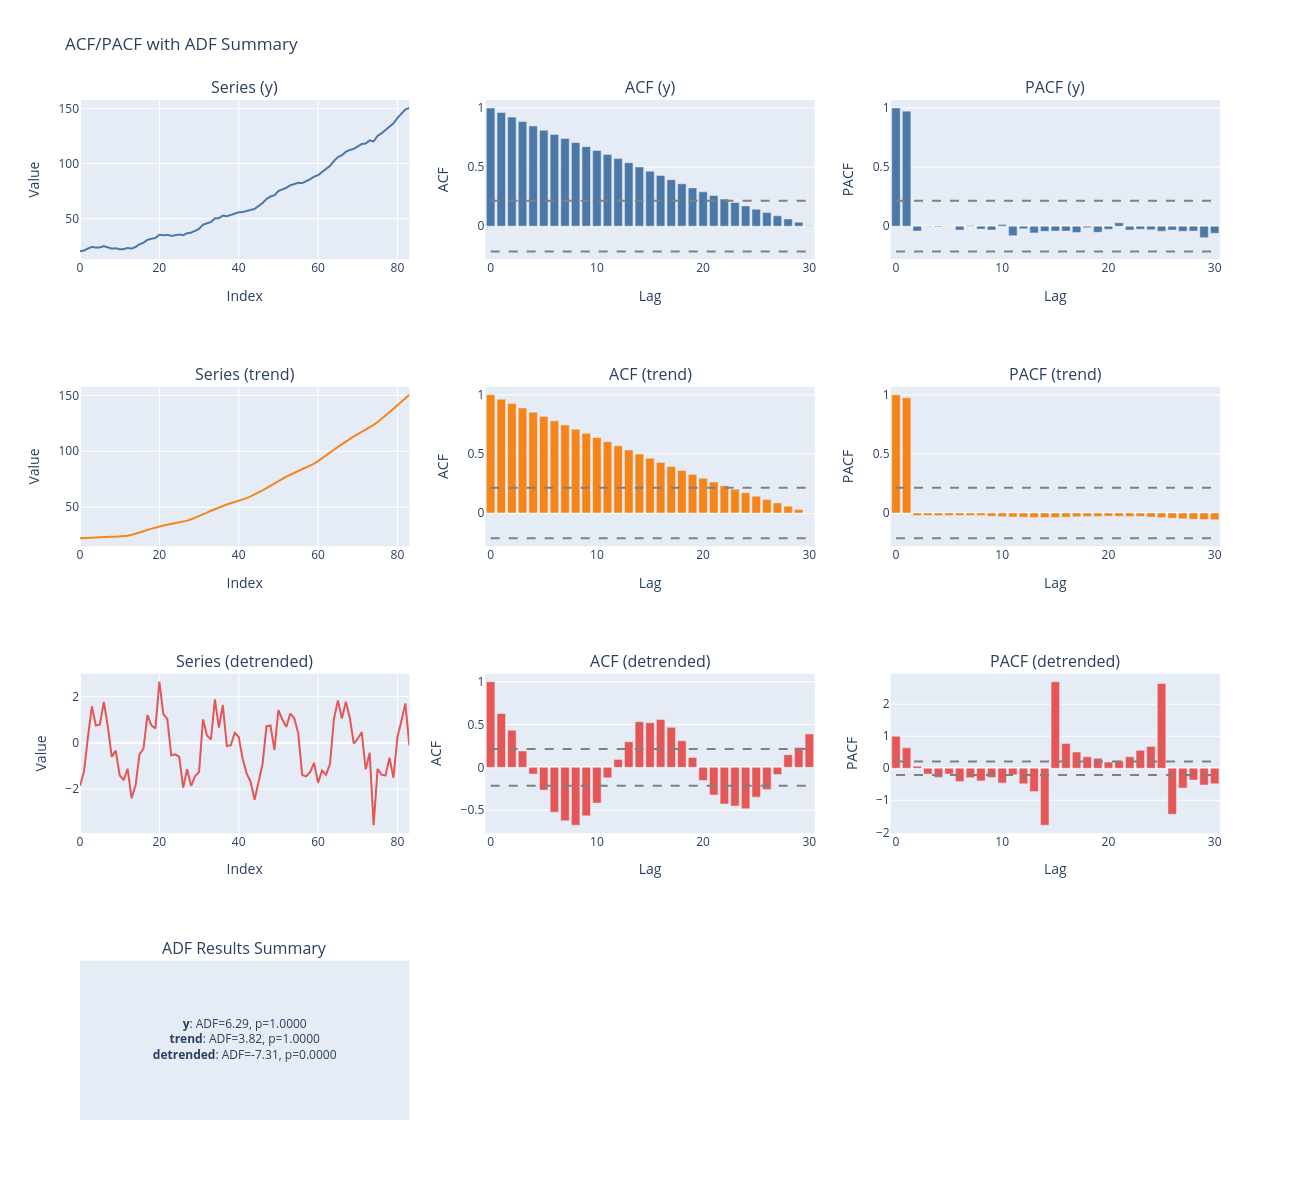

In [6]:
stationarity_analysis(
    diagnostic_components.loc[:,diagnostic_components.columns[2:]],
    nlags=30,
    fig_type='png',
)

In [7]:
diagnostic_components

,unique_id,ds,y,trend,detrended
0,series_a,2018-01-01,20.347700,22.198556,-1.850856
1,series_a,2018-02-01,21.191761,22.439609,-1.247848
2,series_a,2018-03-01,22.906772,22.653576,0.253196
3,series_a,2018-04-01,24.431219,22.845969,1.585250
4,series_a,2018-05-01,23.775027,23.023865,0.751162
...,...,...,...,...,...
79,series_a,2024-08-01,136.381291,137.888777,-1.507486
80,series_a,2024-09-01,141.224796,140.974586,0.250210
81,series_a,2024-10-01,145.046878,144.092890,0.953988
82,series_a,2024-11-01,148.951071,147.244156,1.706915


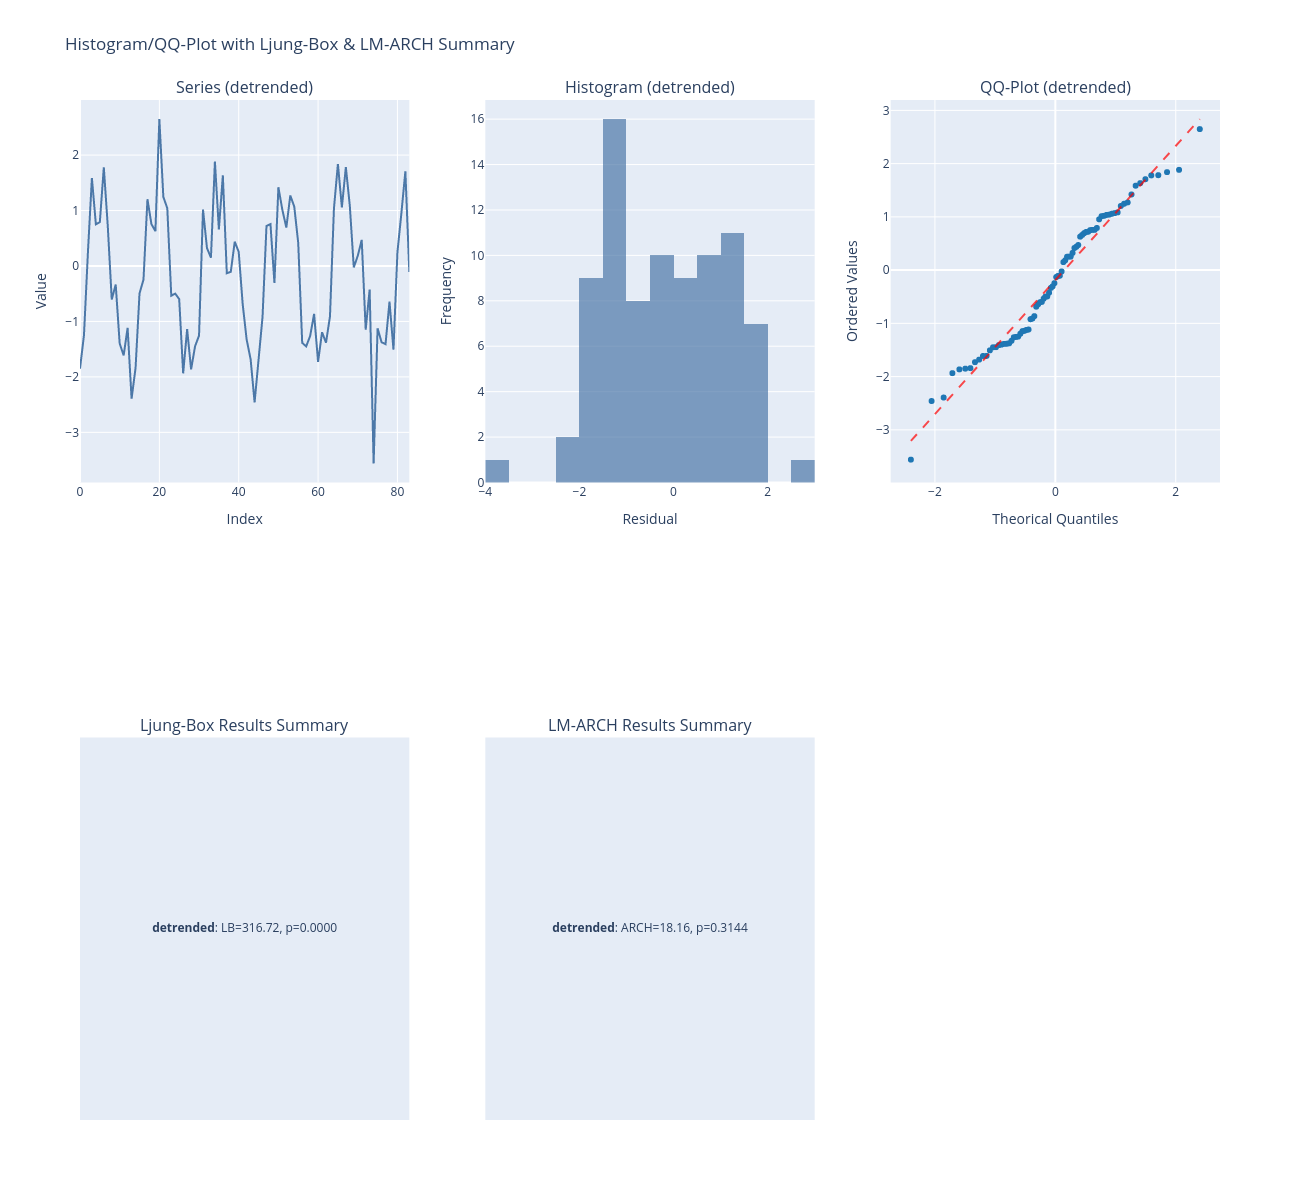

In [8]:
residual_analysis(
    diagnostic_components["detrended"],
    nlags=30,
    fig_type='png',
)

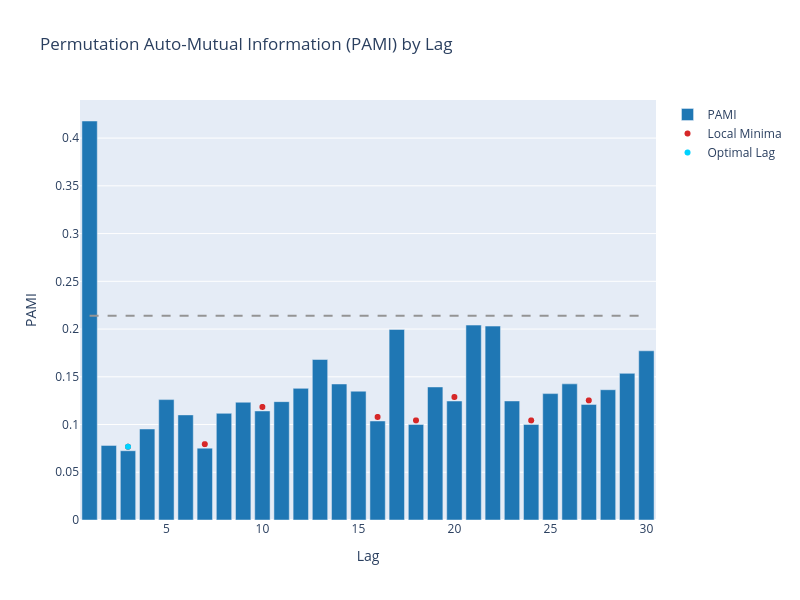

In [9]:
pami(
    diagnostic_components['detrended'],
    nlags=30,
    m=3,
    normalize=True,
    fig_type='png',
)

## Configure the residual forecaster

`mf_resid` is the unfitted residual-model template. DTL creates an isolated fitted copy for each `unique_id`.

In [10]:
models = [LinearRegression(), RandomForestRegressor(n_estimators=100, random_state=42)]

In [11]:
def residual_model_callable(nlags, freq):
    return MLForecast(
        models=models,
        lags=nlags,
        freq=freq,
    )


def callable_trend():
    return AutoETS(
        model="ZAN",
        alias="Trend-AutoETS",
    )


dtl = DTLWrapper(
    residual_model_callable=residual_model_callable,
    freq="MS",
    trend_model_callable=callable_trend,
    nlags="auto",
    pami_params={"max_tau": 24, "m": 3, "delay": 1},
)

In [12]:
dtl.fit(train, id_col='unique_id', time_col='ds', target_col='y')

forecast = dtl.predict(h=horizon)
forecast.head()

,unique_id,ds,LinearRegression,RandomForestRegressor
0,series_a,2025-01-01,153.452553,154.613277
1,series_a,2025-02-01,156.553509,156.291933
2,series_a,2025-03-01,159.142055,158.774606
3,series_a,2025-04-01,162.129986,162.496898
4,series_a,2025-05-01,165.110724,164.277902


## Evaluate the forecasts

The wrapper preserves one prediction column per residual estimator.

In [13]:
actual = test[['unique_id', 'ds', 'y']]
result = forecast.merge(actual, on=['unique_id', 'ds'], how='left')

metrics = evaluate(
    result,
    metrics=metrics,
    models=['LinearRegression', 'RandomForestRegressor'],
    id_col='unique_id',
    time_col='ds',
    target_col='y',
)
metrics

,unique_id,metric,LinearRegression,RandomForestRegressor
0,series_a,rmse,3.394315,3.068451
1,series_b,rmse,5.101538,5.584676
2,series_a,mae,3.124020,2.884890
3,series_b,mae,4.779957,5.225504
4,series_a,bias,3.124020,2.884890
5,series_b,bias,4.779957,5.225504
6,series_a,wape,1.877404,1.733697
7,series_b,wape,3.282885,3.588888
8,series_a,pbias,1.877404,1.733697
9,series_b,pbias,3.282885,3.588888


## Forecast residual analysis

After recombining the LOWESS trend with the ML residual forecast, inspect the remaining forecast errors for each estimator.

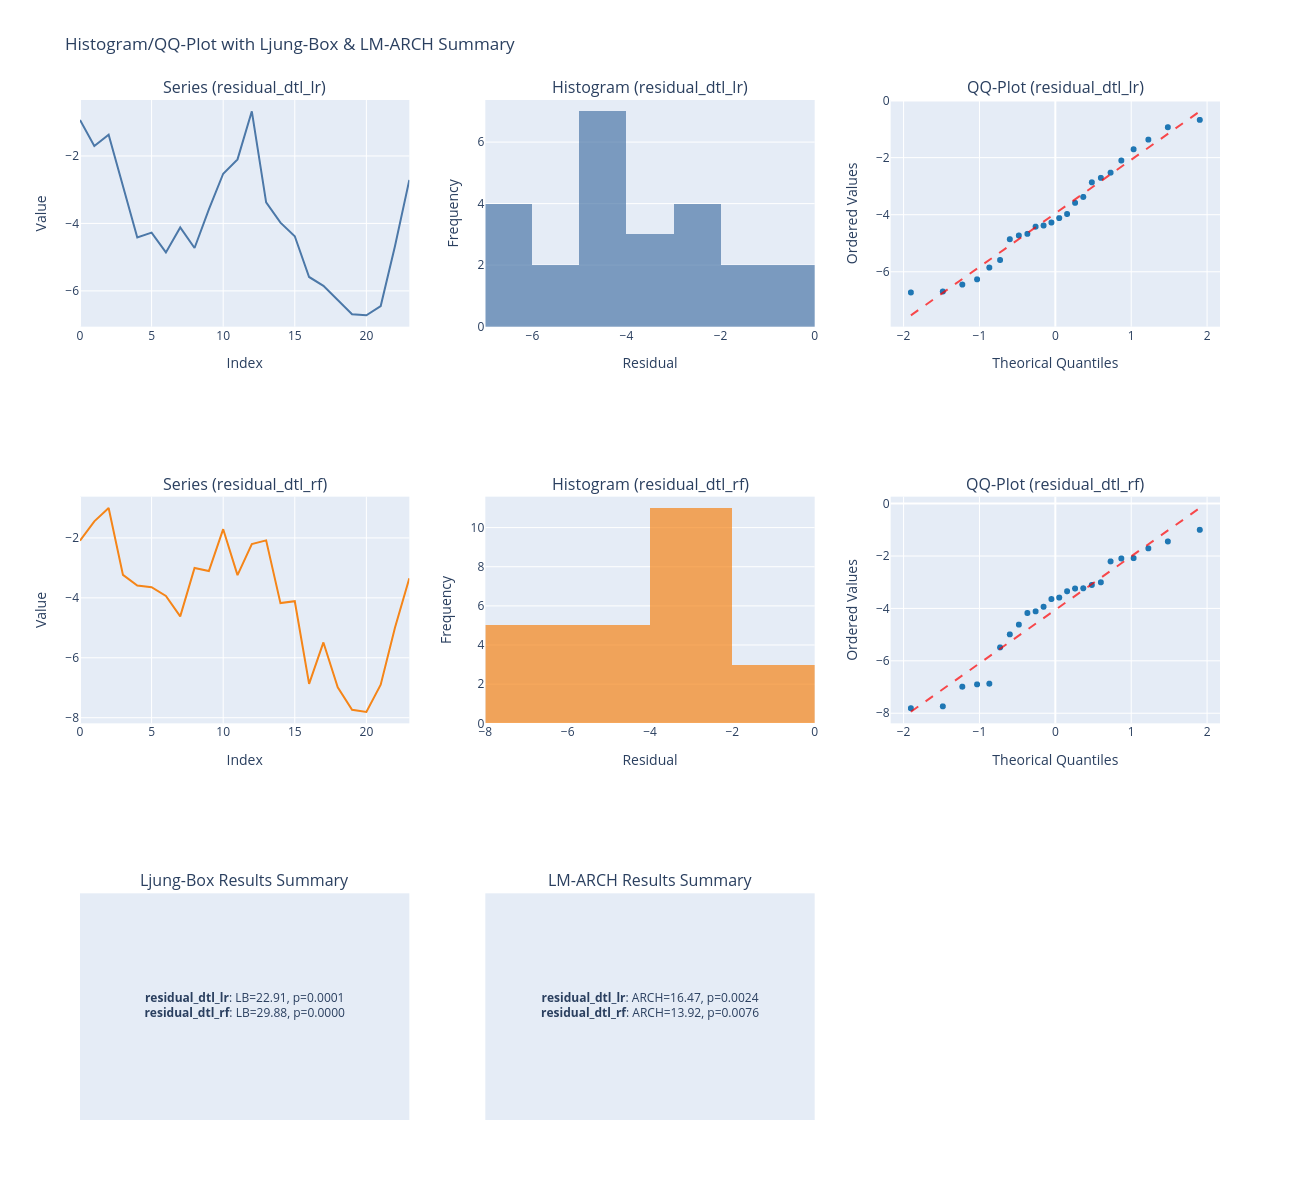

In [14]:
result['residual_dtl_lr'] = result['y'] - result['LinearRegression']
result['residual_dtl_rf'] = result['y'] - result['RandomForestRegressor']

residual_analysis(
    result[['residual_dtl_lr', 'residual_dtl_rf']],
    nlags=30,
    fig_type='png',
)

## Horizontal stabilization

Stabilization can be applied after trend and residual recombination.

In [15]:
stabilized = dtl.predict(
    h=horizon,
    stabilization_method='hfi',
    w_s=0.8,
)[['unique_id', 'ds', 'RandomForestRegressor']]

stabilized.head()

,unique_id,ds,RandomForestRegressor
0,series_a,2025-01-01,154.613277
1,series_a,2025-02-01,154.949008
2,series_a,2025-03-01,155.714128
3,series_a,2025-04-01,157.070682
4,series_a,2025-05-01,158.512126


In [16]:
rf_prediction = result['RandomForestRegressor'].to_numpy()
actual_values = result['y'].to_numpy()
fva_rmae(actual_values, rf_prediction, baseline_type='naive')

0.8897074158370214

## Exog Var

In [19]:
exog_train = train.copy()
exog_train["promotion"] = exog_train["ds"].dt.month.isin([3, 9]).astype(float)


def dtl_residual_model_with_exog(nlags, freq):
    return MLForecast(
        models=[LinearRegression()],
        lags=nlags,
        freq=freq,
    )


exog_dtl = DTLWrapper(
    residual_model_callable=dtl_residual_model_with_exog,
    freq="MS",
    trend_model_callable=callable_trend,
    nlags=[1, 5],
)

exog_dtl.fit(
    exog_train,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    static_features=[],
)

,residual_model_callable,<function dtl...x76e1702d7d80>
,freq,'MS'
,trend_model_callable,<function cal...x76e1702d6de0>
,trend_frac,0.2
,robust,True
,log_transform,False
,nlags,"[1, 5]"
,pami_params,{}


In [21]:
exog_future = test[["unique_id", "ds"]].copy()
exog_future["promotion"] = exog_future["ds"].dt.month.isin([3, 9]).astype(float)

exog_dtl_forecast = exog_dtl.predict(
    h=horizon,
    X_df=exog_future,
)

exog_dtl_forecast

,unique_id,ds,LinearRegression
0,series_a,2025-01-01,153.589604
1,series_a,2025-02-01,156.333219
2,series_a,2025-03-01,158.606887
3,series_a,2025-04-01,161.357226
4,series_a,2025-05-01,164.603934
5,series_a,2025-06-01,167.661481
6,series_a,2025-07-01,170.725434
7,series_a,2025-08-01,173.901654
8,series_a,2025-09-01,176.648808
9,series_a,2025-10-01,179.794574
